# **Duelo Entre Modelos**

### **Modelo Tradicional (Sem Cross Validation)**

Esse modelo segue o fluxo classico de treino e teste em uma unica divisao dos dados. E uma estrategia direta, simples de explicar e muito utilizada quando precisamos de resultados rapidos.

#### **Pontos Fortes**

**Implementacao Simples:** Fluxo direto de treino e avaliacao.

**Rapidez:** Ideal para iteracoes iniciais e testes exploratorios.

**Leitura Objetiva:** Facil de interpretar quando o objetivo e uma primeira referencia de desempenho.

#### **Pontos Fracos**

**Maior Sensibilidade a Divisao:** O resultado depende fortemente de como os dados foram separados.

**Risco de Avaliacao Otimista ou Pessimista:** Uma unica particao pode nao representar bem o comportamento real do modelo.

**Menor Robustez Estatistica:** Ha menos evidencia sobre a estabilidade da performance.

### **Modelo com Cross Validation**

Aqui o modelo e treinado e avaliado em diferentes particoes dos dados. Essa estrategia reduz o impacto de uma divisao especifica e tende a entregar uma visao mais confiavel da capacidade de generalizacao.

#### **Pontos Fortes**

**Avaliacao Mais Robusta:** O modelo e testado em multiplos subconjuntos.

**Menor Risco de Overfitting na Avaliacao:** Reduz o efeito de sorte em uma unica divisao.

**Melhor Estimativa de Generalizacao:** Tende a refletir melhor o desempenho em dados novos.

# **Base de Dados**

Neste duelo, vamos usar uma base focada em saude fetal, ligada a um tema extremamente relevante: reducao da mortalidade infantil e materna.

A base contem exames cardiotocograficos e atributos clinicos importantes para classificacao do estado fetal.

Apos a analise por obstetras especialistas, cada exame foi classificado em uma das seguintes classes:

**Normal:** Exame sem sinais de anormalidade.

**Suspeito:** Caso que exige maior observacao e monitoramento.

**Patologico:** Indicativos de risco fetal, com necessidade de atencao imediata.

In [34]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para os modelos de machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [35]:
base = pd.read_csv('../../Base de Dados/fetal_health.csv')

In [36]:
base.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [37]:
base.dtypes

baseline value                                            float64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                           float64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability    float64
mean_value_of_long_term_variability                       float64
histogram_width                                           float64
histogram_min                                             float64
histogram_max                                             float64
histogram_number_of_peaks                                 float64
histogram_

In [38]:
base.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

### **Analise Exploratoria dos Dados**

Como estamos lidando com uma base nova e bastante rica em informacao, vamos primeiro explorar os dados para entender distribuicoes, padroes e possiveis desequilibrios entre classes.

In [39]:
distribuicao = base['fetal_health'].value_counts()
print(distribuicao)

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64


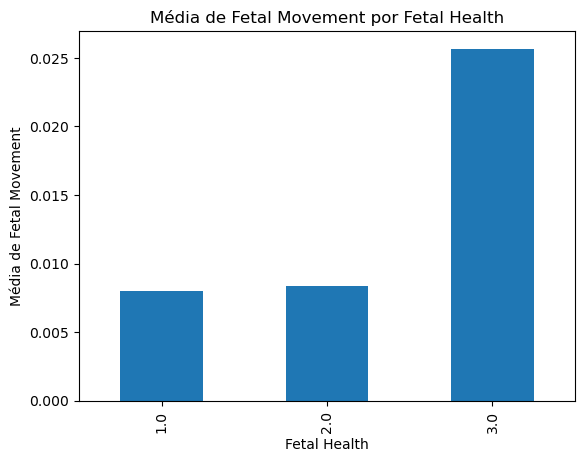

In [40]:
# média de fetal_movement para cada classe de fetal_health
mean_fetal_movement = base.groupby('fetal_health')['fetal_movement'].mean()

mean_fetal_movement.plot(kind='bar')
plt.title('Média de Fetal Movement por Fetal Health')
plt.xlabel('Fetal Health')
plt.ylabel('Média de Fetal Movement')
plt.show()

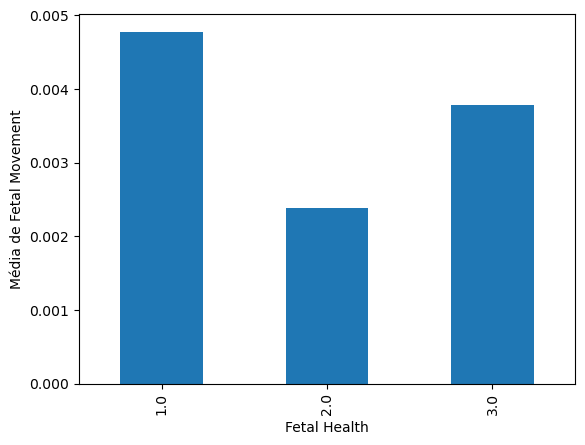

In [41]:
# média de uterine_contractions para cada classe de fetal_health
mean_fetal_movement = base.groupby('fetal_health')['uterine_contractions'].mean()

mean_fetal_movement.plot(kind='bar')
plt.xlabel('Fetal Health')
plt.ylabel('Média de Fetal Movement')
plt.show()

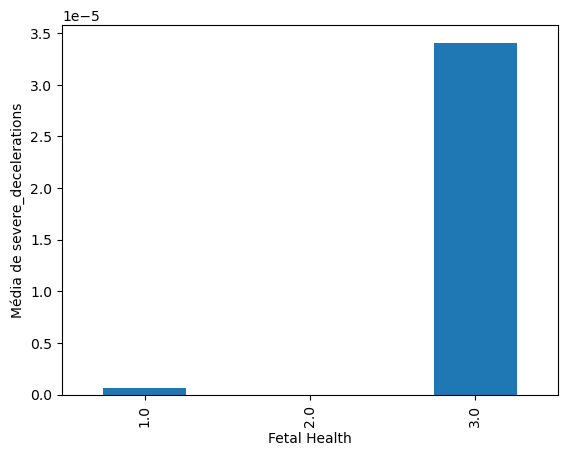

In [42]:
# média de severe_decelerations para cada classe de fetal_health
mean_fetal_movement = base.groupby('fetal_health')['severe_decelerations'].mean()

mean_fetal_movement.plot(kind='bar')
plt.xlabel('Fetal Health')
plt.ylabel('Média de severe_decelerations')
plt.show()

<Axes: >

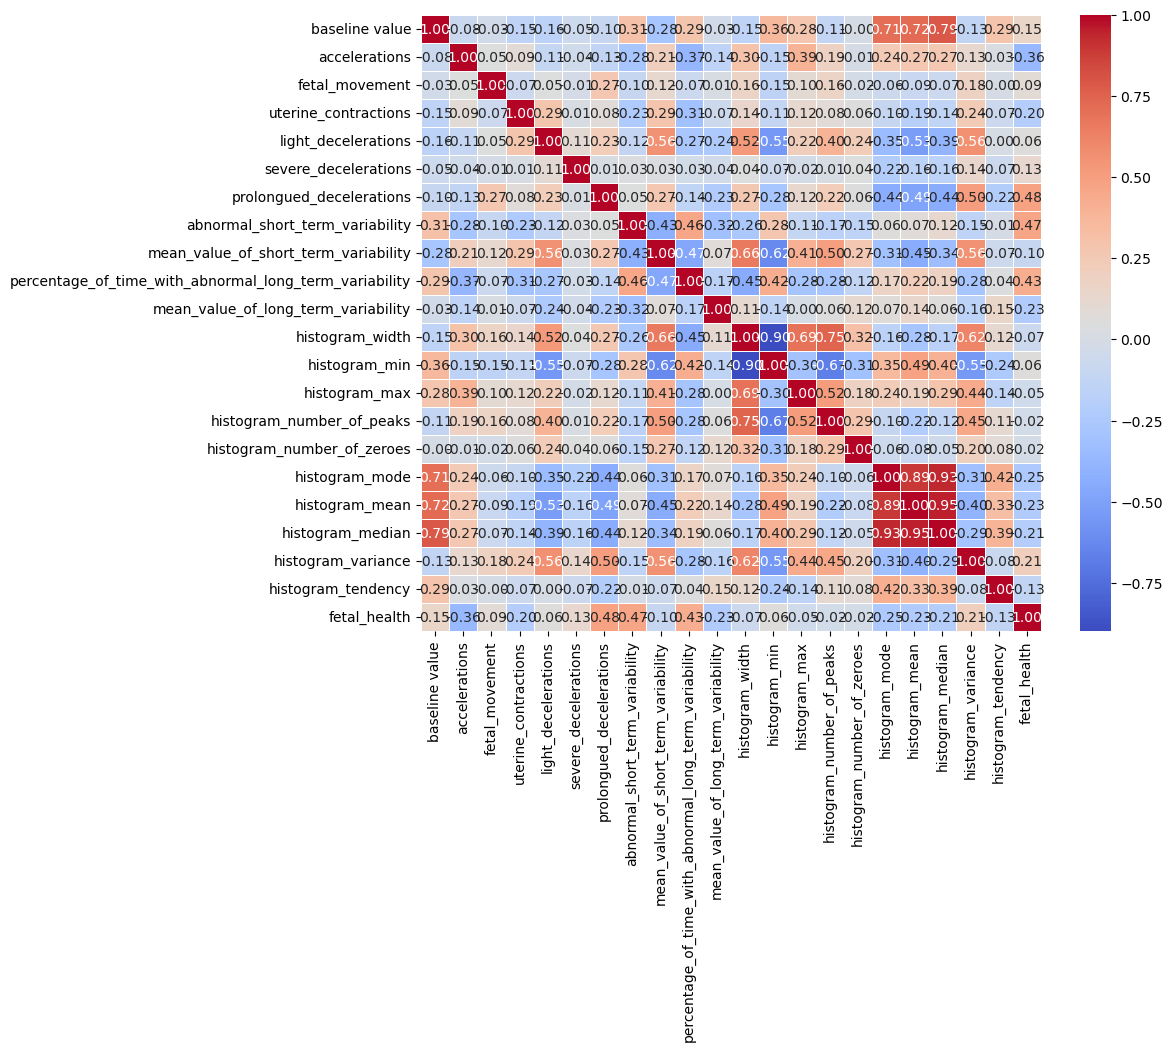

In [43]:
correlation_matrix = base.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

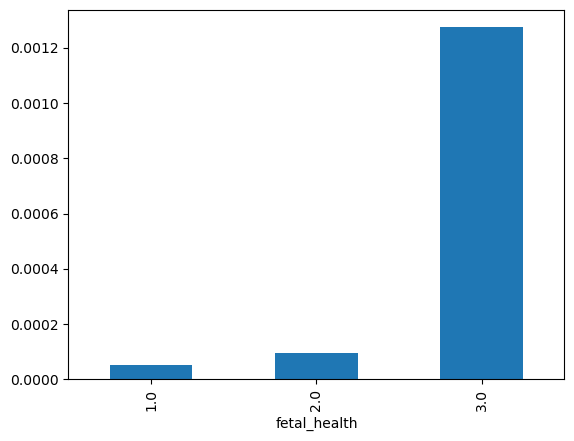

In [44]:
mean_fetal_movement = base.groupby('fetal_health')['prolongued_decelerations'].mean()

mean_fetal_movement.plot(kind='bar')
plt.show()

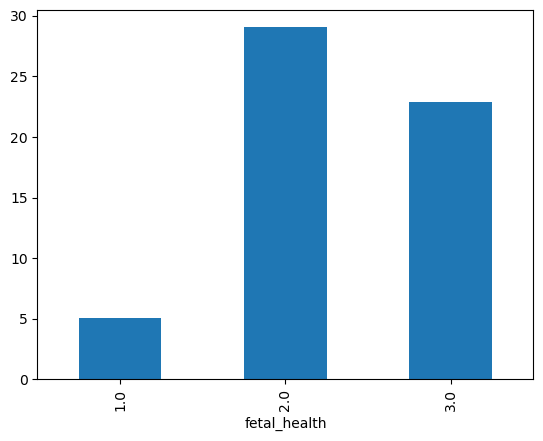

In [45]:
mean_fetal_movement = base.groupby('fetal_health')['percentage_of_time_with_abnormal_long_term_variability'].mean()

mean_fetal_movement.plot(kind='bar')
plt.show()

# **Teste 1**

**Dados sem pre-processamento**

### **Sem Cross Validation**

In [46]:
X = base.drop(columns='fetal_health')
Y = base['fetal_health']

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [48]:
duelo1_scv = RandomForestClassifier(n_estimators=100, random_state=42)

In [49]:
duelo1_scv.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [50]:
Y_pred = duelo1_scv.predict(X_test)

In [51]:
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:")
print(report)

Acurácia: 0.95
Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.89      0.77      0.82        64
         3.0       0.90      0.93      0.92        29

    accuracy                           0.95       426
   macro avg       0.92      0.89      0.90       426
weighted avg       0.94      0.95      0.94       426



### **Com Cross Validation**

In [52]:
duelo1_cv = RandomForestClassifier(n_estimators=100, random_state=42)

In [53]:
cv_scores = cross_val_score(duelo1_cv, X, Y, cv=5)  # cv=5 define 5-fold cross-validation

In [54]:
print(f"Scores de Cross-Validation: {cv_scores}")
print(f"Acurácia Média: {np.mean(cv_scores):.2f}")
print(f"Desvio Padrão: {np.std(cv_scores):.2f}")

Scores de Cross-Validation: [0.87558685 0.90352941 0.92       0.87058824 0.75058824]
Acurácia Média: 0.86
Desvio Padrão: 0.06


No primeiro round, os dois modelos apresentam bons resultados, mas com comportamentos diferentes:

**Sem Cross Validation:** tende a mostrar acuracia alta rapidamente, porem mais sensivel a divisao escolhida.

**Com Cross Validation:** costuma apresentar uma estimativa mais conservadora, mas geralmente mais confiavel para dados novos.

O objetivo da cross validation nao e apenas maximizar a acuracia em um unico recorte, e sim medir consistencia de desempenho em diferentes amostras de treino e validacao.

Em outras palavras, um resultado excelente em uma unica divisao pode ser ocasional. A validacao cruzada ajuda a reduzir esse risco e traz uma avaliacao mais robusta da capacidade de generalizacao.

# **Teste 2**

**Com ajuste de hiperparametros**

Nesta etapa, os modelos recebem tuning de hiperparametros para avaliar quem melhora mais quando ajustamos configuracoes finas de treinamento.

### **Modelo Sem Cross Validation**

In [55]:
# Começamos definindo nossos hyperparametros
best_params = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10)
}

`randint` e usado para sortear valores inteiros dentro de um intervalo, o que torna a busca de hiperparametros mais eficiente em espacos grandes.

No `RandomizedSearchCV`, ele ajuda a testar combinacoes variadas sem precisar percorrer todas as possibilidades do grid completo.

In [56]:
# Em seguida criamos nosso modelo
duelo2_cv = RandomForestClassifier(random_state=42)

In [57]:
# Configuramoa o modelo com os melhores parâmetros
random_search = RandomizedSearchCV(
    estimator=duelo2_cv,
    param_distributions=best_params,
    n_iter=100,  # Número de iterações da busca
    random_state=42,
    n_jobs=-1  # Usar todos os núcleos disponíveis
)

In [58]:
#treinamos nosso modelo com os melhores parametros
random_search.fit(X_train, Y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c0759fcfd10>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c0759fa8fc0>},
                   random_state=42)

In [59]:
best_params_encontrados = random_search.best_params_
print("Melhores Parâmetros Encontrados:", best_params_encontrados)

Melhores Parâmetros Encontrados: {'max_depth': 20, 'min_samples_split': 4, 'n_estimators': 121}


In [60]:
y_pred = random_search.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Acurácia: {accuracy:.2f}")

report = classification_report(Y_test, y_pred)
print("Relatório de Classificação:")
print(report)

Acurácia: 0.95
Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.86      0.80      0.83        64
         3.0       0.90      0.93      0.92        29

    accuracy                           0.95       426
   macro avg       0.91      0.90      0.90       426
weighted avg       0.94      0.95      0.95       426



### **Modelo com Cross Validation**

In [61]:
best_params = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10)
}

In [62]:
random_search_cv = RandomizedSearchCV(
    estimator=duelo2_cv,
    param_distributions=best_params,
    n_iter=100,  # Número de iterações da busca
    cv=5,  # Número de folds da validação cruzada
    random_state=42,
    n_jobs=-1
)

Com `cv=5`, a validacao cruzada divide os dados de treino em 5 partes.

Em cada iteracao, 4 partes sao usadas para treino e 1 para validacao, repetindo o processo ate que todas as partes tenham sido usadas como validacao.

In [63]:
random_search_cv.fit(X_train, Y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c075a007bd0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c075a3639b0>},
                   random_state=42)

In [64]:
melhor_pontuacao = random_search_cv.best_score_
print(f"Melhor Pontuação durante a CV: {melhor_pontuacao:.2f}")

Melhor Pontuação durante a CV: 0.94


In [65]:
best_params_cv = random_search_cv.best_params_
print("Melhores Parâmetros Encontrados:", best_params_cv)

Melhores Parâmetros Encontrados: {'max_depth': 20, 'min_samples_split': 4, 'n_estimators': 121}


In [66]:
y_pred_cv = random_search_cv.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred_cv)
print(f"Acurácia: {accuracy:.2f}")

report = classification_report(Y_test, y_pred_cv)
print("Relatório de Classificação:")
print(report)

Acurácia: 0.95
Relatório de Classificação:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.86      0.80      0.83        64
         3.0       0.90      0.93      0.92        29

    accuracy                           0.95       426
   macro avg       0.91      0.90      0.90       426
weighted avg       0.94      0.95      0.95       426



A busca usa `X_train` e `Y_train` como base. Internamente, o `RandomizedSearchCV` cria os folds da validacao cruzada e avalia diferentes combinacoes de hiperparametros nesses mesmos dados de treino.

Durante a busca, o `RandomizedSearchCV` treina e valida o modelo em multiplas combinacoes de hiperparametros.

Depois de encontrar a melhor configuracao, o estimador final e ajustado com todo o conjunto de treino para ficar pronto para avaliacao no conjunto de teste.